# OULAD Modeling - XGBoost + CatBoost + Tabular DL 

Notebook huan luyen 3 base models co Optuna tuning:
- XGBoost
- CatBoost
- Tabular Deep Learning (PyTorch MLP)

Ensemble models:
- Stacking
- Soft voting

In [1]:
# Cell 2: Import thư viện, khai báo seed/đường dẫn, và nạp dữ liệu train-test đã FE.
import os
import json
import time
import copy
import random
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

print('Imports OK')

Imports OK


In [2]:
# =========================
# Cell 3: Thiết lập hyperparameter chung, seed, tên nhãn và đường dẫn lưu model.
# Cấu hình
# =========================
RANDOM_SEED = 42
OPTUNA_TRIALS = 50
N_FOLDS = 5
VAL_SIZE = 0.2
NUM_CLASSES = 2

LABEL_MAP = {0: 'Not At-Risk', 1: 'At-Risk'}

DATA_PATH = '/kaggle/input/notebooks/danielndap/ews-thuongg/'

SAVE_DIR = '/kaggle/working/saved_models_xgb_cat_tabdl_stacking'
os.makedirs(SAVE_DIR, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print(f'DATA_PATH: {DATA_PATH}')
print(f'DEVICE: {DEVICE}')
print(f'OPTUNA_TRIALS: {OPTUNA_TRIALS}')

DATA_PATH: /kaggle/input/notebooks/danielndap/ews-thuongg/
DEVICE: cuda
OPTUNA_TRIALS: 50


In [3]:
# =========================
# Cell 4: Đọc dữ liệu scaled, chọn feature, tạo X/y train-test và tập validation nội bộ.
# Nạp dữ liệu
# =========================
start_time = time.time()

# Đọc 2 tập đã scale từ notebook feature engineering.
df_train_scaled = pd.read_csv(os.path.join(DATA_PATH, 'df_train_scaled.csv'))
df_test_scaled = pd.read_csv(os.path.join(DATA_PATH, 'df_test_scaled.csv'))

feature_json = os.path.join(DATA_PATH, 'feature_cols.json')
if os.path.exists(feature_json):
    with open(feature_json, 'r') as f:
        feature_cols = json.load(f)
    feature_cols = [c for c in feature_cols if c != 'target']
else:
    exclude = {'target'}
    feature_cols = [c for c in df_train_scaled.columns if c not in exclude]

X_train = df_train_scaled[feature_cols].values.astype(np.float32)
y_train = df_train_scaled['target'].values.astype(int)
X_test = df_test_scaled[feature_cols].values.astype(np.float32)
y_test = df_test_scaled['target'].values.astype(int)

# Tách thêm validation nội bộ để Optuna/tối ưu tham số không đụng vào tập test cuối.
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=VAL_SIZE,
    shuffle=False
)

print(f'Train shape: {X_train.shape} | Test shape: {X_test.shape}')
print(f'Num features: {len(feature_cols)}')
print(f'Data loaded in {time.time()-start_time:.2f}s')

Train shape: (21333, 32) | Test shape: (11260, 32)
Num features: 32
Data loaded in 0.62s


In [4]:
# Cell 5: Hàm đánh giá thống nhất cho tất cả model (binary classification).
def evaluate_model(name, y_true, y_pred, y_prob=None, show_plot=True):
    # Tính bộ metric cho binary classification.
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='binary')
    rec = recall_score(y_true, y_pred, average='binary')
    f1_bin = f1_score(y_true, y_pred, average='binary')

    # AUC-ROC nếu có probability
    auc_roc = None
    if y_prob is not None:
        auc_roc = roc_auc_score(y_true, y_prob)

    print('\n' + '=' * 60)
    print(name)
    print('=' * 60)
    print(f'Accuracy:    {acc:.4f}')
    print(f'Precision:   {prec:.4f}')
    print(f'Recall:      {rec:.4f}')
    print(f'F1 (binary): {f1_bin:.4f}  << PRIMARY')
    if auc_roc is not None:
        print(f'AUC-ROC:     {auc_roc:.4f}')
    print(classification_report(y_true, y_pred, target_names=[LABEL_MAP[i] for i in range(NUM_CLASSES)]))

    if show_plot:
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=[LABEL_MAP[i] for i in range(NUM_CLASSES)],
                    yticklabels=[LABEL_MAP[i] for i in range(NUM_CLASSES)])
        plt.title(f'CM: {name}')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.tight_layout()
        plt.show()

    result = {
        'name': name,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_binary': f1_bin,
    }
    if auc_roc is not None:
        result['auc_roc'] = auc_roc
    return result


XGBOOST + OPTUNA
Best Val F1-binary: 0.8565 (45.5s)

XGBoost
Accuracy:    0.8587
Precision:   0.9041
Recall:      0.8120
F1 (binary): 0.8556  << PRIMARY
AUC-ROC:     0.9267
              precision    recall  f1-score   support

 Not At-Risk       0.82      0.91      0.86      5457
     At-Risk       0.90      0.81      0.86      5803

    accuracy                           0.86     11260
   macro avg       0.86      0.86      0.86     11260
weighted avg       0.86      0.86      0.86     11260



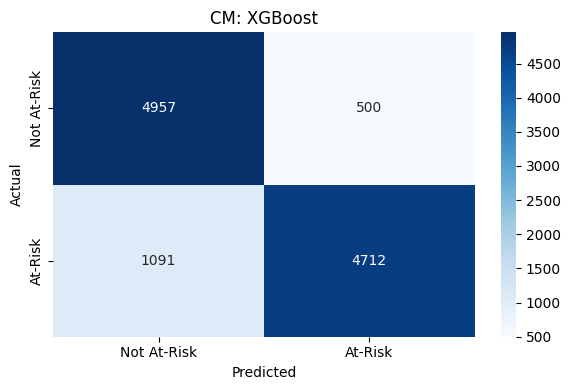

In [5]:
# =========================
# Cell 7: Tune XGBoost bằng Optuna trên validation và đánh giá trên test.
# XGBoost + Optuna (Tối ưu tham số) - Binary Classification
# =========================
print('\n' + '='*60)
print('XGBOOST + OPTUNA')
print('='*60)

t0 = time.time()

# Optuna objective: tìm bộ tham số XGBoost tối ưu theo F1 binary trên validation.
def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1200),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        # Binary classification: logistic regression objective.
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'random_state': RANDOM_SEED,
        'verbosity': 0,
        'tree_method': 'hist',
    }

    if torch.cuda.is_available():
        params['device'] = 'cuda'

    model = XGBClassifier(**params)
    model.fit(X_tr, y_tr, verbose=False)
    pred = model.predict(X_val)
    return f1_score(y_val, pred, average='binary')

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(xgb_objective, n_trials=OPTUNA_TRIALS)
print(f'Best Val F1-binary: {study_xgb.best_value:.4f} ({time.time()-t0:.1f}s)')

best_xgb_params = study_xgb.best_params
best_xgb_params.update({
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'random_state': RANDOM_SEED,
    'verbosity': 0,
    'tree_method': 'hist',
})
if torch.cuda.is_available():
    best_xgb_params['device'] = 'cuda'

best_xgb = XGBClassifier(**best_xgb_params)
best_xgb.fit(X_train, y_train, verbose=False)
xgb_pred = best_xgb.predict(X_test)
xgb_prob = best_xgb.predict_proba(X_test)[:, 1]
result_xgb = evaluate_model('XGBoost', y_test, xgb_pred, y_prob=xgb_prob)


CATBOOST + OPTUNA
Best Val F1-binary: 0.8770 (2094.6s)

CatBoost
Accuracy:    0.8632
Precision:   0.9094
Recall:      0.8160
F1 (binary): 0.8601  << PRIMARY
AUC-ROC:     0.9340
              precision    recall  f1-score   support

 Not At-Risk       0.82      0.91      0.87      5457
     At-Risk       0.91      0.82      0.86      5803

    accuracy                           0.86     11260
   macro avg       0.87      0.86      0.86     11260
weighted avg       0.87      0.86      0.86     11260



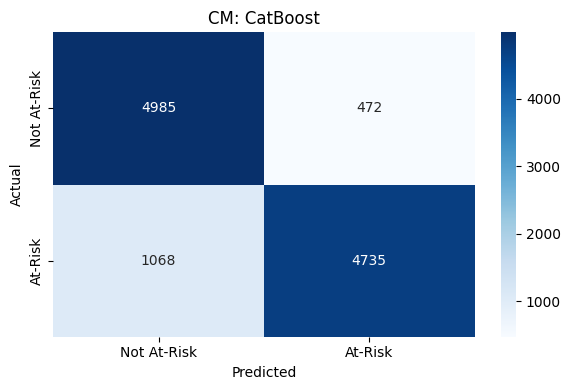

In [6]:
# =========================
# Cell 8: Tune CatBoost bằng Optuna, train model tốt nhất và báo cáo kết quả.
# CatBoost + Optuna (Tối ưu tham số) - Binary Classification
# =========================
print('\n' + '='*60)
print('CATBOOST + OPTUNA')
print('='*60)

t0 = time.time()

# Optuna objective: tối ưu CatBoost theo F1 binary trên validation.
def cat_objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 300, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth': trial.suggest_int('depth', 3, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 0.0, 10.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        # Binary classification: Logloss objective.
        'loss_function': 'Logloss',
        'random_seed': RANDOM_SEED,
        'verbose': 0,
    }

    if torch.cuda.is_available():
        params['task_type'] = 'GPU'

    model = CatBoostClassifier(**params)
    model.fit(X_tr, y_tr)
    pred = model.predict(X_val).astype(int).reshape(-1)
    return f1_score(y_val, pred, average='binary')

study_cat = optuna.create_study(direction='maximize')
study_cat.optimize(cat_objective, n_trials=OPTUNA_TRIALS)
print(f'Best Val F1-binary: {study_cat.best_value:.4f} ({time.time()-t0:.1f}s)')

best_cat_params = study_cat.best_params
best_cat_params.update({
    'loss_function': 'Logloss',
    'random_seed': RANDOM_SEED,
    'verbose': 0,
})
if torch.cuda.is_available():
    best_cat_params['task_type'] = 'GPU'

best_cat = CatBoostClassifier(**best_cat_params)
best_cat.fit(X_train, y_train)
cat_pred = best_cat.predict(X_test).astype(int).reshape(-1)
cat_prob = best_cat.predict_proba(X_test)[:, 1]
result_cat = evaluate_model('CatBoost', y_test, cat_pred, y_prob=cat_prob)

In [7]:
# =========================
# Cell 6: Các hàm hỗ trợ xây dựng và huấn luyện mô hình Tabular DL (MLP)
# =========================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import copy
from sklearn.metrics import f1_score
import numpy as np

class TabularMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout, num_classes=2):
        super().__init__()
        layers = []
        in_dim = input_dim
        for _ in range(num_layers):
            layers.append(nn.Linear(in_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.Dropout(dropout))
            in_dim = hidden_dim
        layers.append(nn.Linear(in_dim, num_classes))
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.network(x)

def train_tabdl_once(X_tr, y_tr, X_val, y_val, params, device):
    input_dim = X_tr.shape[1]
    model = TabularMLP(input_dim, params['hidden_dim'], params['num_layers'], params['dropout'], NUM_CLASSES)
    model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=params['lr'], weight_decay=params['weight_decay'])
    
    train_dataset = TensorDataset(torch.FloatTensor(X_tr), torch.LongTensor(y_tr))
    val_dataset = TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val))
    
    train_loader = DataLoader(train_dataset, batch_size=params['batch_size'], shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=params['batch_size'], shuffle=False)
    
    best_f1 = -1.0
    best_weights = None
    patience_counter = 0
    
    for epoch in range(params.get('epochs', 50)):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
        model.eval()
        preds = []
        trues = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                outputs = model(X_batch)
                pred = torch.argmax(outputs, dim=1).cpu().numpy()
                preds.extend(pred)
                trues.extend(y_batch.numpy())
                
        val_f1 = f1_score(trues, preds, average='binary')
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= params.get('patience', 10):
                break
                
    if best_weights is not None:
        model.load_state_dict(best_weights)
    return model, best_f1

def predict_proba_tabdl(model, X, batch_size, device):
    model.eval()
    dataset = TensorDataset(torch.FloatTensor(X))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    probas = []
    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch[0].to(device)
            outputs = model(X_batch)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            probas.append(probs)
    return np.vstack(probas)


TABULAR DL (MLP) + OPTUNA
Best Val F1-binary: 0.8699 (526.3s)

Tabular DL (MLP)
Accuracy:    0.8626
Precision:   0.9143
Recall:      0.8092
F1 (binary): 0.8586  << PRIMARY
AUC-ROC:     0.9312
              precision    recall  f1-score   support

 Not At-Risk       0.82      0.92      0.87      5457
     At-Risk       0.91      0.81      0.86      5803

    accuracy                           0.86     11260
   macro avg       0.87      0.86      0.86     11260
weighted avg       0.87      0.86      0.86     11260



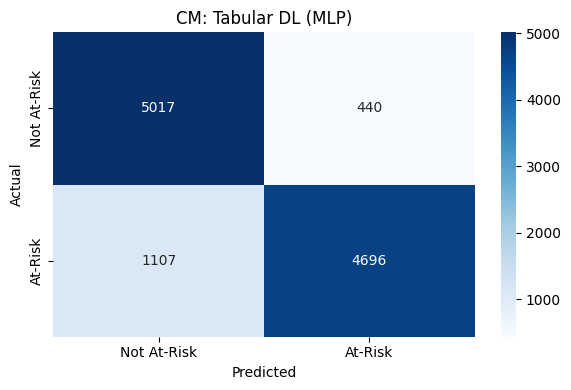

In [8]:
# =========================
# Cell 9: Tune TabularDL bang Optuna, train model tot nhat - Binary Classification
# =========================
print('\n' + '='*60)
print('TABULAR DL (MLP) + OPTUNA')
print('='*60)

t0 = time.time()

def tabdl_objective(trial):
    params = {
        'hidden_dim': trial.suggest_int('hidden_dim', 64, 512),
        'num_layers': trial.suggest_int('num_layers', 1, 5),
        'dropout': trial.suggest_float('dropout', 0.0, 0.5),
        'batch_size': trial.suggest_categorical('batch_size', [128, 256, 512]),
        'lr': trial.suggest_float('lr', 1e-4, 1e-2, log=True),
        'weight_decay': trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True),
        'epochs': 50,
        'patience': 10,
    }
    model, best_f1 = train_tabdl_once(X_tr, y_tr, X_val, y_val, params, device=DEVICE)
    return best_f1  # f1_score average='binary' (da set o train_tabdl_once)

study_tabdl = optuna.create_study(direction='maximize')
study_tabdl.optimize(tabdl_objective, n_trials=OPTUNA_TRIALS)
print(f'Best Val F1-binary: {study_tabdl.best_value:.4f} ({time.time()-t0:.1f}s)')

best_tabdl_params = study_tabdl.best_params
best_tabdl_params.update({'epochs': 100, 'patience': 15})

# Train model cuoi tren full X_train voi internal val split cho early stopping
X_tr_final, X_val_final, y_tr_final, y_val_final = train_test_split(
    X_train, y_train, test_size=VAL_SIZE, shuffle=False
)
best_tabdl, _ = train_tabdl_once(X_tr_final, y_tr_final, X_val_final, y_val_final, best_tabdl_params, device=DEVICE)

tabdl_proba = predict_proba_tabdl(best_tabdl, X_test, batch_size=1024, device=DEVICE)
best_tabdl_predict = np.argmax(tabdl_proba, axis=1)
tabdl_prob = tabdl_proba[:, 1]
result_tabdl = evaluate_model('Tabular DL (MLP)', y_test, best_tabdl_predict, y_prob=tabdl_prob)

STACKING (OOF) - XGB + CAT + TABDL
Fold 1/5 | train=3558 val=3555
Fold 2/5 | train=7113 val=3555
Fold 3/5 | train=10668 val=3555
Fold 4/5 | train=14223 val=3555
Fold 5/5 | train=17778 val=3555

Stacking (OOF + LogisticRegression)
Accuracy:    0.8604
Precision:   0.9013
Recall:      0.8187
F1 (binary): 0.8580  << PRIMARY
AUC-ROC:     0.9311
              precision    recall  f1-score   support

 Not At-Risk       0.82      0.90      0.86      5457
     At-Risk       0.90      0.82      0.86      5803

    accuracy                           0.86     11260
   macro avg       0.86      0.86      0.86     11260
weighted avg       0.86      0.86      0.86     11260



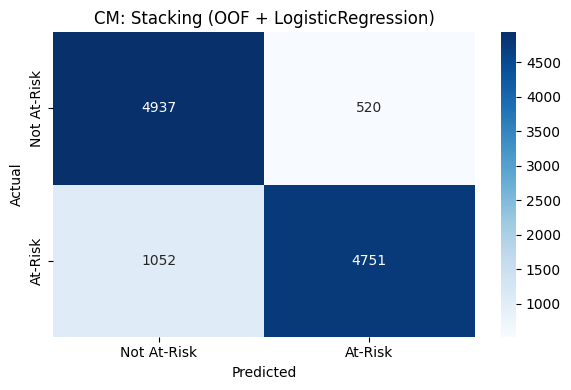

OOF stacking completed in 89.6s


In [9]:
from sklearn.model_selection import TimeSeriesSplit
# =========================
# Cell 10: Tạo OOF predictions từ base models để train meta-model và tránh leakage.
# Stacking Ensemble (OOF, chống leakage)
# =========================
print('STACKING (OOF) - XGB + CAT + TABDL')

t0 = time.time()
skf = TimeSeriesSplit(n_splits=N_FOLDS)

# Xác suất OOF
n_train = len(y_train)
n_test = len(y_test)
# OOF predictions trên train cho từng base model; đây là đầu vào train cho meta-model.
oof_xgb = np.zeros((n_train, NUM_CLASSES), dtype=np.float32)
oof_cat = np.zeros((n_train, NUM_CLASSES), dtype=np.float32)
oof_tab = np.zeros((n_train, NUM_CLASSES), dtype=np.float32)

test_xgb = np.zeros((n_test, NUM_CLASSES), dtype=np.float32)
test_cat = np.zeros((n_test, NUM_CLASSES), dtype=np.float32)
test_tab = np.zeros((n_test, NUM_CLASSES), dtype=np.float32)

# Vòng lặp OOF: mỗi fold tạo dự đoán trên tập validation chưa gặp để tránh leakage.
for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train, y_train), 1):
    print(f'Fold {fold}/{N_FOLDS} | train={len(tr_idx)} val={len(va_idx)}')
    Xf_tr, yf_tr = X_train[tr_idx], y_train[tr_idx]
    Xf_va, yf_va = X_train[va_idx], y_train[va_idx]

    # Mô hình XGBoost
    m_xgb = XGBClassifier(**best_xgb_params)
    m_xgb.fit(Xf_tr, yf_tr, verbose=False)
    oof_xgb[va_idx] = m_xgb.predict_proba(Xf_va)
    test_xgb += m_xgb.predict_proba(X_test) / N_FOLDS

    # Mô hình CatBoost
    m_cat = CatBoostClassifier(**best_cat_params)
    m_cat.fit(Xf_tr, yf_tr)
    oof_cat[va_idx] = m_cat.predict_proba(Xf_va)
    test_cat += m_cat.predict_proba(X_test) / N_FOLDS

    # Mô hình Tabular DL
    m_tab, _ = train_tabdl_once(Xf_tr, yf_tr, Xf_va, yf_va, best_tabdl_params, device=DEVICE)
    oof_tab[va_idx] = predict_proba_tabdl(m_tab, Xf_va, batch_size=1024, device=DEVICE)
    test_tab += predict_proba_tabdl(m_tab, X_test, batch_size=1024, device=DEVICE) / N_FOLDS

# Meta feature: 3 model x 2 xac suat = 6 dac trung
meta_train = np.hstack([oof_xgb, oof_cat, oof_tab])
meta_test = np.hstack([test_xgb, test_cat, test_tab])

# Meta-model học cách kết hợp dự đoán base models; LR đa lớp giúp đơn giản và khó overfit.
meta_learner = LogisticRegression(
    max_iter=2000,
        solver='lbfgs',
    random_state=RANDOM_SEED
)
meta_learner.fit(meta_train, y_train)

y_pred_stack = meta_learner.predict(meta_test)
y_prob_stack = meta_learner.predict_proba(meta_test)[:, 1]
result_stack = evaluate_model('Stacking (OOF + LogisticRegression)', y_test, y_pred_stack, y_prob=y_prob_stack)
print(f'OOF stacking completed in {time.time() - t0:.1f}s')


Soft Voting (Equal: XGB+Cat+TabDL)
Accuracy:    0.8604
Precision:   0.9052
Recall:      0.8144
F1 (binary): 0.8574  << PRIMARY
AUC-ROC:     0.9306
              precision    recall  f1-score   support

 Not At-Risk       0.82      0.91      0.86      5457
     At-Risk       0.91      0.81      0.86      5803

    accuracy                           0.86     11260
   macro avg       0.86      0.86      0.86     11260
weighted avg       0.86      0.86      0.86     11260



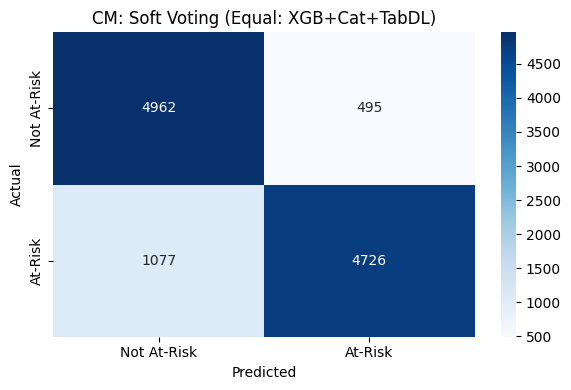


Ranking by F1-binary:
                                  name  accuracy  precision    recall  \
0                             CatBoost  0.863233   0.909353  0.815957   
1                     Tabular DL (MLP)  0.862611   0.914330  0.809237   
2  Stacking (OOF + LogisticRegression)  0.860391   0.901347  0.818714   
3   Soft Voting (Equal: XGB+Cat+TabDL)  0.860391   0.905191  0.814406   
4                              XGBoost  0.858703   0.904068  0.811994   

   f1_binary   auc_roc  
0   0.860127  0.934007  
1   0.858579  0.931159  
2   0.858046  0.931132  
3   0.857402  0.930573  
4   0.855561  0.926713  

Best model: CatBoost | F1-binary=0.8601


In [10]:
# =========================
# Cell 11: Soft voting va tong ket ket qua - Binary Classification
# =========================
prob_soft = (test_xgb + test_cat + test_tab) / 3
y_pred_soft = np.argmax(prob_soft, axis=1)
y_prob_soft = prob_soft[:, 1]
result_soft = evaluate_model('Soft Voting (Equal: XGB+Cat+TabDL)', y_test, y_pred_soft, y_prob=y_prob_soft)

results = [result_xgb, result_cat, result_tabdl, result_stack, result_soft]
results_df = pd.DataFrame(results).sort_values('f1_binary', ascending=False).reset_index(drop=True)
print('\nRanking by F1-binary:')
cols = [c for c in ['name', 'accuracy', 'precision', 'recall', 'f1_binary', 'auc_roc'] if c in results_df.columns]
print(results_df[cols])

best_result = results_df.iloc[0].to_dict()
print(f"\nBest model: {best_result['name']} | F1-binary={best_result['f1_binary']:.4f}")

In [11]:

# =========================
# Cell 12: Lưu tất cả model/optuna study và metadata để tái sử dụng khi deploy.
# Lưu models + metadata
# =========================
with open(os.path.join(SAVE_DIR, 'xgboost_best.pkl'), 'wb') as f:
    pickle.dump(best_xgb, f)
with open(os.path.join(SAVE_DIR, 'catboost_best.pkl'), 'wb') as f:
    pickle.dump(best_cat, f)

# Mô hình torch
torch.save(best_tabdl.state_dict(), os.path.join(SAVE_DIR, 'tabdl_best.pt'))
with open(os.path.join(SAVE_DIR, 'tabdl_arch.json'), 'w') as f:
    json.dump({
        'input_dim': int(X_train.shape[1]),
        'num_classes': NUM_CLASSES,
        **best_tabdl_params
    }, f, indent=2)

with open(os.path.join(SAVE_DIR, 'meta_learner.pkl'), 'wb') as f:
    pickle.dump(meta_learner, f)

with open(os.path.join(SAVE_DIR, 'optuna_xgb.pkl'), 'wb') as f:
    pickle.dump(study_xgb, f)
with open(os.path.join(SAVE_DIR, 'optuna_cat.pkl'), 'wb') as f:
    pickle.dump(study_cat, f)
with open(os.path.join(SAVE_DIR, 'optuna_tabdl.pkl'), 'wb') as f:
    pickle.dump(study_tabdl, f)

metadata = {
    'version': 'xgb_cat_tabdl_stacking_binary_v1',
    'primary_metric': 'f1_binary',
    'n_features': len(feature_cols),
    'feature_cols': feature_cols,
    'models': ['XGBoost', 'CatBoost', 'TabularDL(MLP)'],
    'stacking': {
        'n_folds': N_FOLDS,
        'meta_learner': 'LogisticRegression',
        'meta_feature_dim': int(meta_train.shape[1]),
        'anti_leakage': 'OOF predictions via TimeSeriesSplit'
    },
    'results': results,
    'best': best_result,
    'best_params': {
        'xgb': study_xgb.best_params,
        'cat': study_cat.best_params,
        'tabdl': study_tabdl.best_params,
    }
}

with open(os.path.join(SAVE_DIR, 'metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)
# Lưu metadata để phục vụ tải model và dùng đúng feature/cấu hình khi suy luận.
with open(os.path.join(SAVE_DIR, 'metadata.pkl'), 'wb') as f:
    pickle.dump(metadata, f)

print(f'Saved all artifacts to: {SAVE_DIR}')

Saved all artifacts to: /kaggle/working/saved_models_xgb_cat_tabdl_stacking


In [12]:
# =========================
# Cell 13: Nén thư mục kết quả thành file zip để tải xuống/backup.
# Nén thư mục output
# =========================
import shutil

# Đóng gói toàn bộ artifact thành 1 file zip để lưu trữ/chia sẻ.
zip_base = os.path.abspath(SAVE_DIR)
zip_path = shutil.make_archive(zip_base, 'zip', SAVE_DIR)
print(f'Created zip: {zip_path}')

Created zip: /kaggle/working/saved_models_xgb_cat_tabdl_stacking.zip


PHÂN TÍCH SHAP CHO XGBOOST


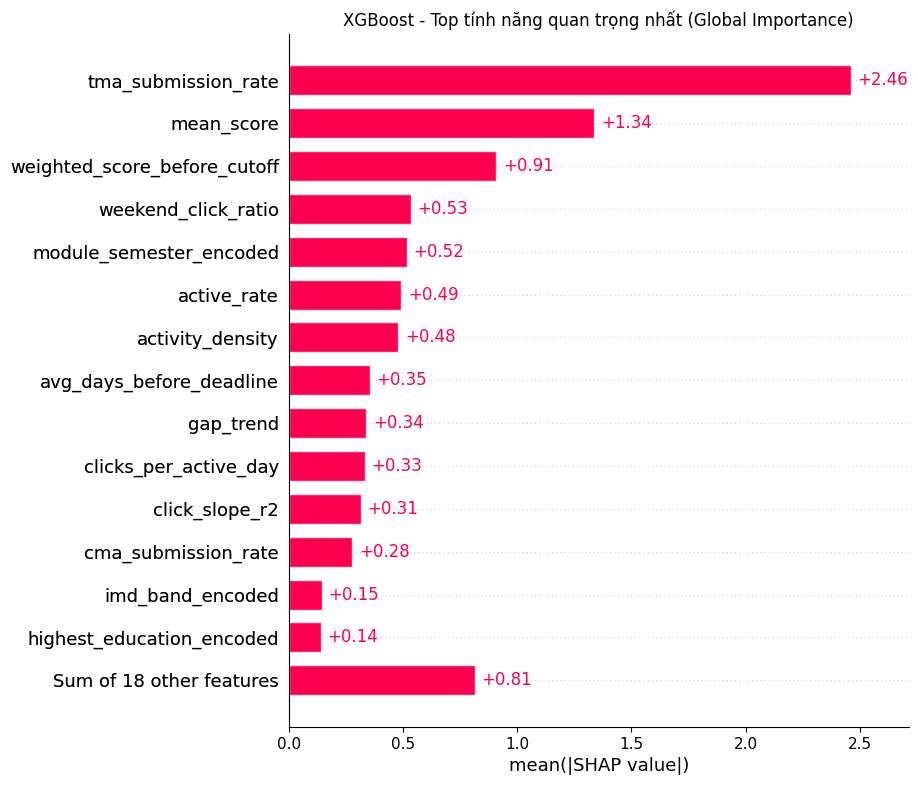

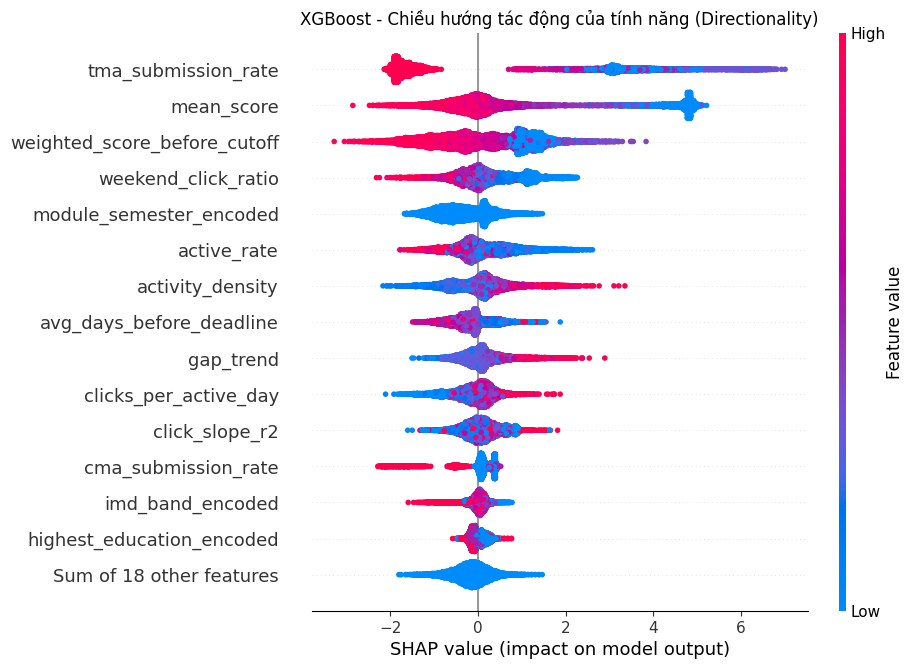


BÓC TÁCH LÝ DO DỰ ĐOÁN CHO SINH VIÊN SỐ 0
- Thực tế sinh viên này: Not At-Risk
- Mô hình dự đoán nguy cơ At-Risk: 17.43%


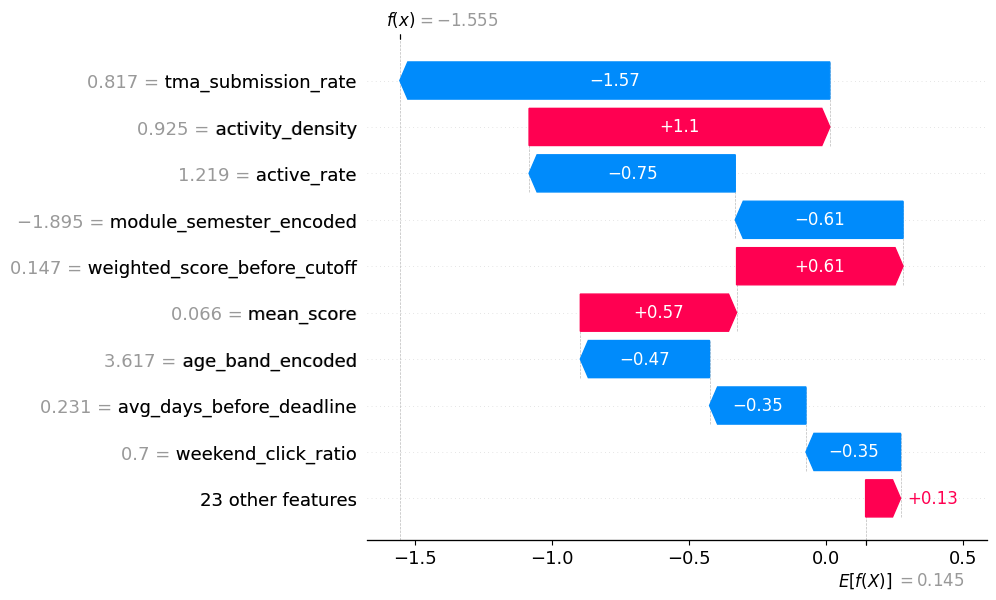

In [13]:

import shap
import pandas as pd
import matplotlib.pyplot as plt

# 1. Chuyển X_test (numpy array) về lại DataFrame để SHAP hiển thị tên cột
X_test_df = pd.DataFrame(X_test, columns=feature_cols)

print("="*60)
print("PHÂN TÍCH SHAP CHO XGBOOST")
print("="*60)

# 2. Khởi tạo TreeExplainer cho mô hình tốt nhất (XGBoost)
# TreeExplainer chạy cực kỳ nhanh và tối ưu cho các mô hình dạng cây
explainer_xgb = shap.TreeExplainer(best_xgb)

# 3. Tính toán SHAP values trên tập Test
# (Có thể mất khoảng 10-30 giây tùy tốc độ máy)
shap_values_xgb = explainer_xgb(X_test_df)

# --- BIỂU ĐỒ 1: TỔNG QUAN ĐỘ QUAN TRỌNG (SHAP BAR PLOT) ---
# Biểu đồ này giống Feature Importance nhưng chính xác hơn
plt.figure()
plt.title("XGBoost - Top tính năng quan trọng nhất (Global Importance)")
shap.plots.bar(shap_values_xgb, max_display=15)
plt.show()

# --- BIỂU ĐỒ 2: CHIỀU HƯỚNG TÁC ĐỘNG (SHAP BEESWARM PLOT) ---
# Màu Đỏ = Giá trị cao, Màu Xanh = Giá trị thấp
# Nằm bên phải trục = Tăng tỷ lệ Rủi ro (At-Risk), Bên trái = Giảm tỷ lệ rủi ro
plt.figure()
plt.title("XGBoost - Chiều hướng tác động của tính năng (Directionality)")
shap.plots.beeswarm(shap_values_xgb, max_display=15)
plt.show()

# --- BIỂU ĐỒ 3: GIẢI THÍCH CHO 1 SINH VIÊN CỤ THỂ (WATERFALL PLOT) ---
# Chọn sinh viên đầu tiên trong tập Test (index = 0)
student_idx = 0
actual_label = LABEL_MAP[y_test[student_idx]]
predicted_prob = best_xgb.predict_proba(X_test)[student_idx, 1]

print("\n" + "="*60)
print(f"BÓC TÁCH LÝ DO DỰ ĐOÁN CHO SINH VIÊN SỐ {student_idx}")
print(f"- Thực tế sinh viên này: {actual_label}")
print(f"- Mô hình dự đoán nguy cơ At-Risk: {predicted_prob:.2%}")
print("="*60)

plt.figure()
# Biểu diễn vì sao mô hình lại đẩy xác suất At-Risk lên cao hay xuống thấp
shap.plots.waterfall(shap_values_xgb[student_idx])
plt.show()


PHÂN TÍCH SHAP CHO CATBOOST


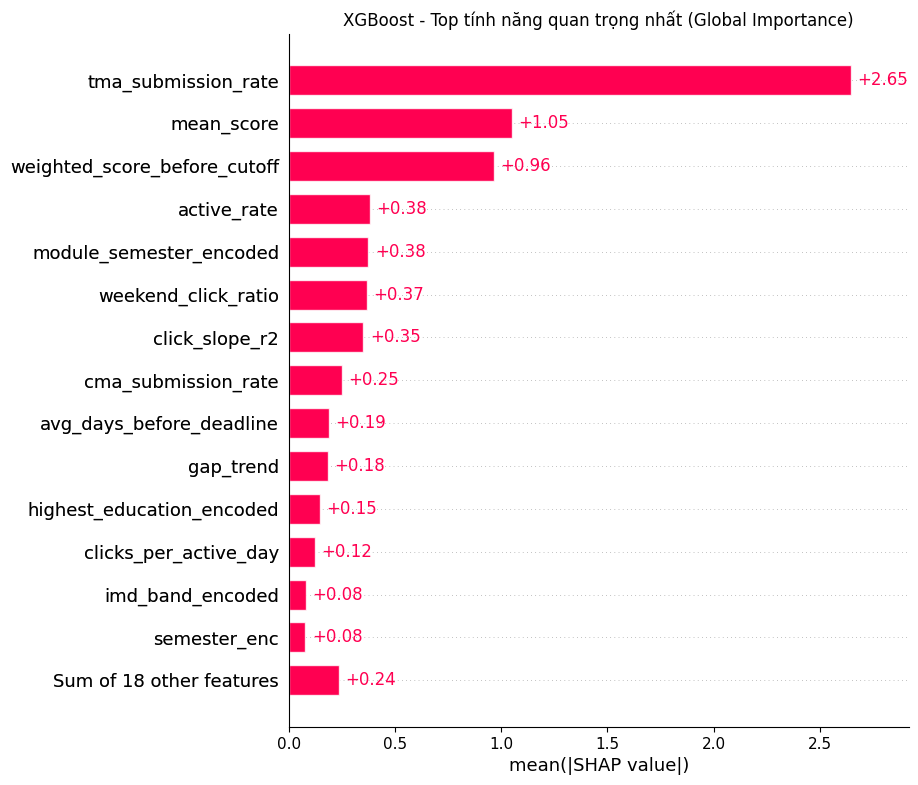

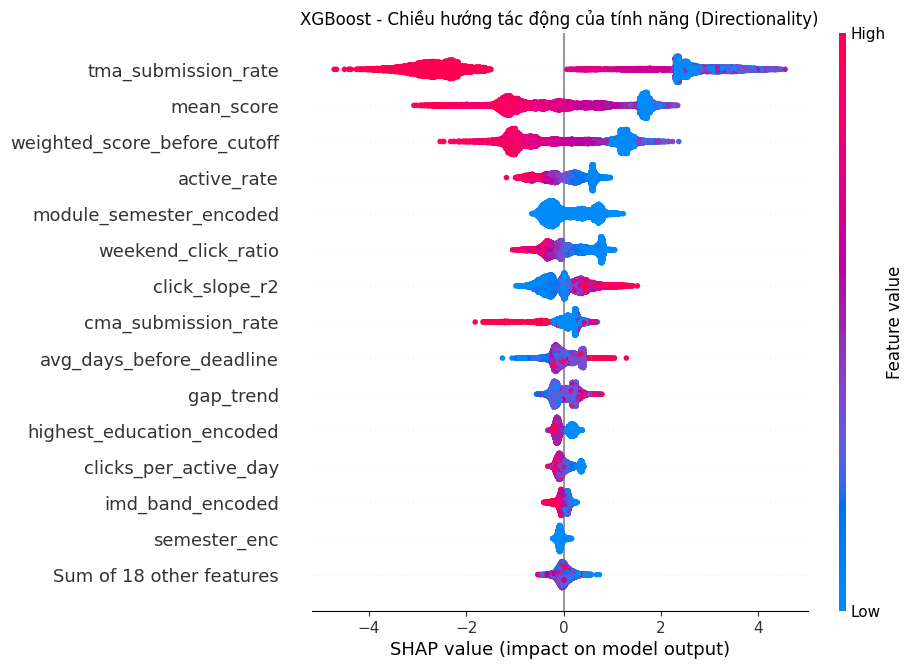


BÓC TÁCH LÝ DO DỰ ĐOÁN CHO SINH VIÊN SỐ 0
- Thực tế sinh viên này: Not At-Risk
- Mô hình dự đoán nguy cơ At-Risk: 17.43%


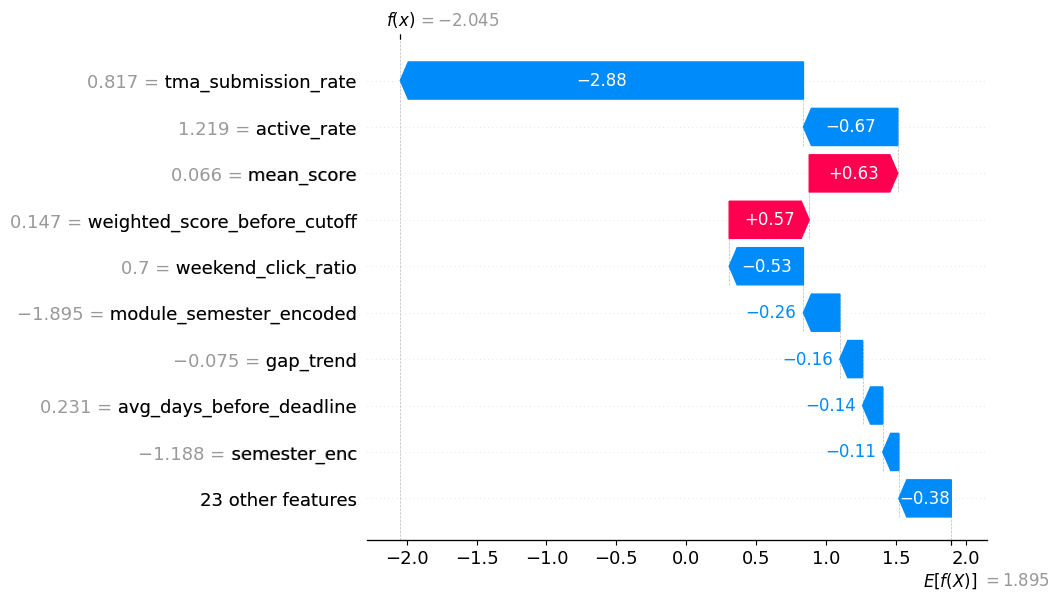

In [14]:



print("="*60)
print("PHÂN TÍCH SHAP CHO CATBOOST")
print("="*60)

# 2. Khởi tạo TreeExplainer cho mô hình tốt nhất (XGBoost)
# TreeExplainer chạy cực kỳ nhanh và tối ưu cho các mô hình dạng cây
explainer_cat = shap.TreeExplainer(best_cat)

# 3. Tính toán SHAP values trên tập Test
# (Có thể mất khoảng 10-30 giây tùy tốc độ máy)
shap_values_cat = explainer_cat(X_test_df)

# --- BIỂU ĐỒ 1: TỔNG QUAN ĐỘ QUAN TRỌNG (SHAP BAR PLOT) ---
# Biểu đồ này giống Feature Importance nhưng chính xác hơn
plt.figure()
plt.title("XGBoost - Top tính năng quan trọng nhất (Global Importance)")
shap.plots.bar(shap_values_cat, max_display=15)
plt.show()

# --- BIỂU ĐỒ 2: CHIỀU HƯỚNG TÁC ĐỘNG (SHAP BEESWARM PLOT) ---
# Màu Đỏ = Giá trị cao, Màu Xanh = Giá trị thấp
# Nằm bên phải trục = Tăng tỷ lệ Rủi ro (At-Risk), Bên trái = Giảm tỷ lệ rủi ro
plt.figure()
plt.title("XGBoost - Chiều hướng tác động của tính năng (Directionality)")
shap.plots.beeswarm(shap_values_cat, max_display=15)
plt.show()

# --- BIỂU ĐỒ 3: GIẢI THÍCH CHO 1 SINH VIÊN CỤ THỂ (WATERFALL PLOT) ---
# Chọn sinh viên đầu tiên trong tập Test (index = 0)
student_idx = 0
actual_label = LABEL_MAP[y_test[student_idx]]
predicted_prob = best_xgb.predict_proba(X_test)[student_idx, 1]

print("\n" + "="*60)
print(f"BÓC TÁCH LÝ DO DỰ ĐOÁN CHO SINH VIÊN SỐ {student_idx}")
print(f"- Thực tế sinh viên này: {actual_label}")
print(f"- Mô hình dự đoán nguy cơ At-Risk: {predicted_prob:.2%}")
print("="*60)

plt.figure()
# Biểu diễn vì sao mô hình lại đẩy xác suất At-Risk lên cao hay xuống thấp
shap.plots.waterfall(shap_values_cat[student_idx])
plt.show()


PHÂN TÍCH SHAP CHO MLP


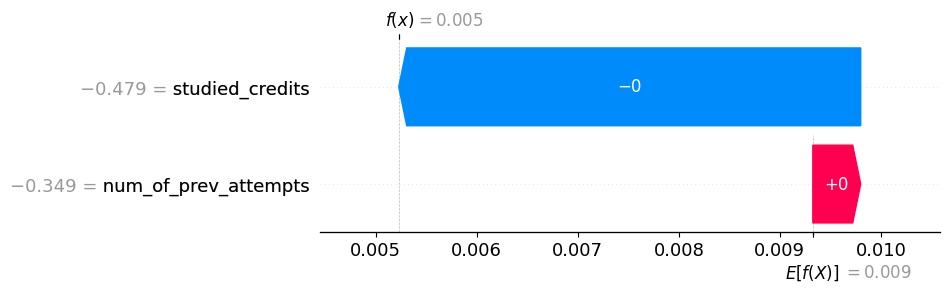

In [15]:

print("="*60)
print("PHÂN TÍCH SHAP CHO MLP")
print("="*60)

# 1. Chuyển mô hình về chế độ đánh giá
best_tabdl.eval()

# 2. Tạo một "tập nền" nhỏ (VD: 500 dòng ngẫu nhiên từ X_train) để SHAP lấy làm gốc tính toán
background_data = torch.FloatTensor(X_train[:500]).to(DEVICE)

# 3. Khởi tạo DeepExplainer
explainer_dl = shap.DeepExplainer(best_tabdl, background_data)

# 4. Lấy 100 bạn sinh viên đầu tiên trong tập Test ra để phân tích (để nhiều quá sẽ chạy rất lâu)
test_data_sample = torch.FloatTensor(X_test[:100]).to(DEVICE)

# 5. Tính SHAP values (Sẽ tốn thời gian)
shap_values_dl = explainer_dl.shap_values(test_data_sample)

# Lưu ý: Kết quả shap_values_dl của PyTorch có thể trả về 1 list (nếu output layer >= 2).
# Bạn chọn index 1 (tương ứng với nhãn At-Risk) để vẽ đồ thị:
shap.plots.waterfall(shap.Explanation(values=shap_values_dl[1][0], 
                                      base_values=explainer_dl.expected_value[1], 
                                      data=X_test[0], 
                                      feature_names=feature_cols))
